# PCG (Phonocardiogram) Advanced Analysis Pipeline

**Modules:**
1. Heart Sound Segmentation — peak-seeded boundary detection
2. Normal vs. Abnormal Classification — rule-based + Isolation Forest  
3. Murmur Detection & Grading — within Nyquist limit

> **Note on Sample Rate:** ESP32 records at 500 Hz (Nyquist = 250 Hz).  
> This captures S1 (20–150 Hz) and most S2 (50–200 Hz) adequately.  
> For murmur analysis above 250 Hz, increase to ≥2000 Hz.

## 0. Install Dependencies

In [ ]:
# !pip install numpy scipy matplotlib PyWavelets librosa scikit-learn

## 1. Imports & Configuration

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.io import wavfile
from scipy.io.wavfile import write as wav_write
from scipy.signal import (butter, filtfilt, iirnotch, find_peaks,
                           savgol_filter, hilbert, spectrogram)
from scipy.ndimage import uniform_filter1d
import pywt
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from IPython.display import display, Markdown, Audio
import warnings
warnings.filterwarnings('ignore')

# Better plot defaults for notebooks
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

print("✓ All imports successful")

✓ All imports successful


In [2]:
# ════════════════════════════════════════════════
# CONFIGURATION — adjust these for your setup
# ════════════════════════════════════════════════

FILENAME       = "/home/aman/Projects/IoMT_Phonocardiography/Recorded Data/aman5-ble.wav"    # ← your WAV file path
LOWCUT         = 25.0           # Bandpass low (Hz) — captures full S1
HIGHCUT        = 200.0          # Bandpass high (Hz) — auto-clamped to Nyquist-1
#NOTCH_FREQ     = 50.0           # Powerline hum: 50 Hz (Europe) / 60 Hz (USA)
NOTCH_FREQS     = (50, 100, 150)
NOTCH_Q         = 35

FILTER_ORDER   = 4              # Butterworth filter order
WAVELET        = 'db6'          # Daubechies-6 wavelet
WAVELET_LEVEL  = 4              # Decomposition depth (4 for 500 Hz SR)
ENVELOPE_CUTOFF = 8.0           # Envelope smoothing lowpass (Hz)
MIN_PEAK_DIST  = 0.25           # Min seconds between detected peaks
BPM_MIN        = 40             # Physiological heart rate limits
BPM_MAX        = 200

# Physiological normal ranges for rule-based screening
NORMAL_RANGES = {
    's1_duration_ms':  (50, 200),
    's2_duration_ms':  (40, 150),
    'systolic_ms':     (150, 450),
    'diastolic_ms':    (150, 1200),
    's1_s2_amp_ratio': (0.5, 3.0),
    'heart_rate_bpm':  (45, 180),
}

# Murmur grading thresholds (energy ratio relative to S1)
MURMUR_GRADE_THRESHOLDS = [0.15, 0.30, 0.50, 0.70, 0.90]

## 2. Signal Processing Filters

In [3]:
#def notch_filter(data, cutoff, fs, Q=30):
    #"""IIR notch filter to remove powerline hum (50/60 Hz)."""
    #b, a = iirnotch(cutoff / (0.5 * fs), Q)
    #return filtfilt(b, a, data)

def multi_notch_filter(data, fs, freqs=(50, 100, 150), Q=35):
    """
    Apply multiple narrow notch filters to remove power-line hum
    and its harmonics.
    """
    filtered = data.copy().astype(float)
    nyq = 0.5 * fs

    for f in freqs:
        if f < nyq - 1.0:
            w0 = f / nyq
            b, a = iirnotch(w0, Q)
            filtered = filtfilt(b, a, filtered)

    return filtered

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth bandpass."""
    nyq = 0.5 * fs
    highcut = min(highcut, nyq - 1.0)
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def lowpass_filter(data, cutoff, fs, order=2):
    """Zero-phase Butterworth lowpass."""
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)

#def wavelet_denoise(data, wavelet='db6', level=4):
    #"""
    #DWT soft-thresholding with Donoho-Johnstone universal threshold.
    #Noise σ estimated via MAD of finest detail coefficients.
    #"""
    #max_lvl = pywt.dwt_max_level(len(data), wavelet)
    #level = min(level, max_lvl)
    #coeffs = pywt.wavedec(data, wavelet, level=level)
    #sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    #threshold = sigma * np.sqrt(2 * np.log(len(data)))
    #denoised = [coeffs[0]]
    #for d in coeffs[1:]:
        #denoised.append(pywt.threshold(d, threshold, mode='soft'))
    #return pywt.waverec(denoised, wavelet)

def wavelet_denoise(data, wavelet='db6', level=4, thresh_scale=0.6):
    coeffs = pywt.wavedec(data, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = thresh_scale * sigma * np.sqrt(2 * np.log(len(data)))
    coeffs_th = [coeffs[0]] + [
        pywt.threshold(c, value=uthresh, mode='soft')
        for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_th, wavelet)

def shannon_envelope(signal, sr, cutoff=8.0):
    """
    Shannon energy envelope: -x² · log(x²)
    Better S1/S2 contrast than simple squaring.
    """
    norm = signal / (np.max(np.abs(signal)) + 1e-10)
    eps = 1e-10
    se = -norm**2 * np.log(norm**2 + eps)
    env = lowpass_filter(se, cutoff, sr)
    return np.maximum(env, 0)

print("✓ Filters defined")

✓ Filters defined


## 3. Load & Preprocess Signal

In [4]:
# Load WAV
sample_rate, raw_data = wavfile.read(FILENAME)
if len(raw_data.shape) > 1:
    raw_data = raw_data[:, 0]  # mono

data = raw_data.astype(np.float64)
data = data - np.mean(data) # Add
n_samples = len(data)
duration = n_samples / sample_rate
nyq = sample_rate / 2.0
time_axis = np.linspace(0, duration, n_samples, endpoint=False)

print(f"File:        {FILENAME}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Nyquist:     {nyq} Hz")
print(f"Duration:    {duration:.2f} s")
print(f"Samples:     {n_samples:,}")

if HIGHCUT >= nyq:
    print(f"⚠ HIGHCUT ({HIGHCUT} Hz) ≥ Nyquist ({nyq} Hz) → clamped to {nyq-1} Hz")

File:        /home/aman/Projects/IoMT_Phonocardiography/Recorded Data/aman5-ble.wav
Sample rate: 500 Hz
Nyquist:     250.0 Hz
Duration:    23.02 s
Samples:     11,510


In [ ]:
# Listen to the raw recording
Audio(data=raw_data, rate=sample_rate)

In [5]:
# ── Apply filter pipeline ──
# Stage 1: Notch (remove powerline hum)
#data_notched = notch_filter(data, NOTCH_FREQ, sample_rate)
data_notched = multi_notch_filter(data, sample_rate, freqs=NOTCH_FREQS, Q=NOTCH_Q)

# Stage 2: Bandpass (keep heart sound frequencies)
data_bp = bandpass_filter(data_notched, LOWCUT, HIGHCUT, sample_rate, FILTER_ORDER)

# Stage 3: Wavelet denoise
#data_denoised = wavelet_denoise(data_bp, WAVELET, WAVELET_LEVEL)[:n_samples]

data_denoised = wavelet_denoise(
    data_bp,
    WAVELET,
    WAVELET_LEVEL,
    thresh_scale=0.6
)[:n_samples]

# Stage 4: Savitzky-Golay smooth
filtered = savgol_filter(data_denoised, window_length=11, polyorder=3)

print("✓ Filter pipeline complete")

✓ Filter pipeline complete


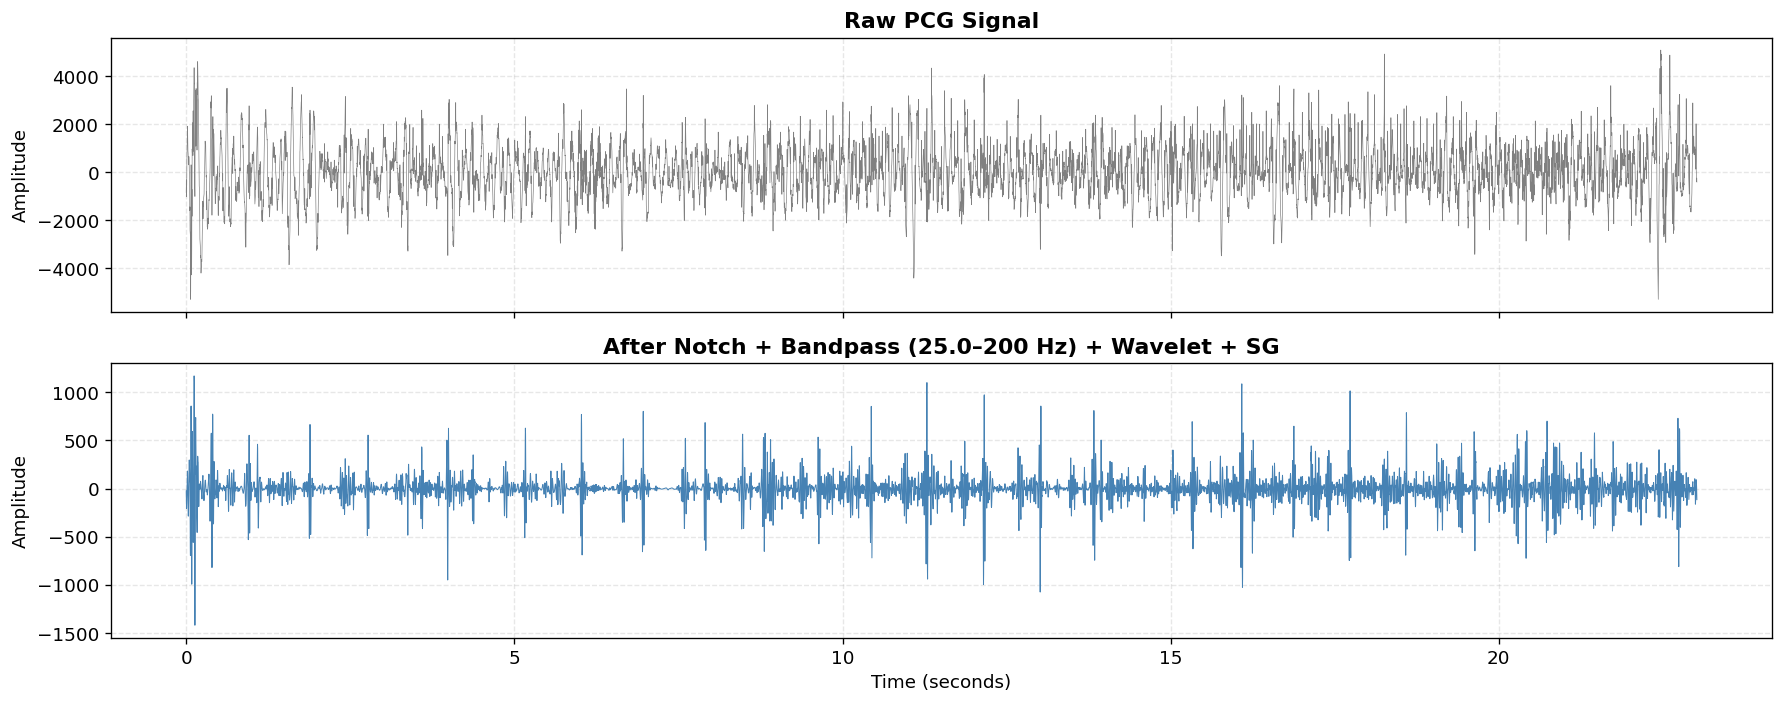

In [6]:
# Compare raw vs filtered
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].plot(time_axis, raw_data, color='gray', lw=0.4)
axes[0].set_title('Raw PCG Signal', fontweight='bold')
axes[0].set_ylabel('Amplitude')

axes[1].plot(time_axis, filtered, color='steelblue', lw=0.6)
axes[1].set_title(f'After Notch + Bandpass ({LOWCUT}–{min(HIGHCUT, nyq-1):.0f} Hz) + Wavelet + SG',
                  fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [7]:
# Listen to the filtered signal
filtered_norm = filtered / (np.max(np.abs(filtered)) + 1e-10)
Audio(data=filtered_norm, rate=sample_rate)

In [8]:
output_filename = 'filtered_norm.wav'
wav_write(output_filename, sample_rate, (filtered_norm * 32767).astype(np.int16))
print(f"✓ Saved: {output_filename}")

✓ Saved: filtered_norm.wav


## 4. Envelope & S1/S2 Peak Detection

In [9]:
# Shannon energy envelope
envelope = shannon_envelope(filtered, sample_rate, ENVELOPE_CUTOFF)

# Adaptive peak detection
threshold = np.percentile(envelope, 75)
peaks, _ = find_peaks(envelope, height=threshold,
                       distance=int(sample_rate * MIN_PEAK_DIST),
                       prominence=threshold * 0.3)

# S1/S2 classification by interval ratio
# Principle: systole (S1→S2) is shorter than diastole (S2→next S1)
s1_peaks, s2_peaks = [], []
if len(peaks) >= 3:
    pt = peaks / sample_rate
    for i in range(len(peaks) - 2):
        i1 = pt[i+1] - pt[i]
        i2 = pt[i+2] - pt[i+1]
        if i1 < i2:  # short interval = systole → first peak is S1
            if peaks[i] not in s1_peaks: s1_peaks.append(peaks[i])
            if peaks[i+1] not in s2_peaks: s2_peaks.append(peaks[i+1])
        else:
            if peaks[i] not in s2_peaks: s2_peaks.append(peaks[i])
            if peaks[i+1] not in s1_peaks: s1_peaks.append(peaks[i+1])

s1_peaks = np.array(sorted(set(s1_peaks)))
s2_peaks = np.array(sorted(set(s2_peaks)))

print(f"Peaks detected: {len(peaks)}")
print(f"S1 peaks: {len(s1_peaks)}")
print(f"S2 peaks: {len(s2_peaks)}")

Peaks detected: 54
S1 peaks: 31
S2 peaks: 31


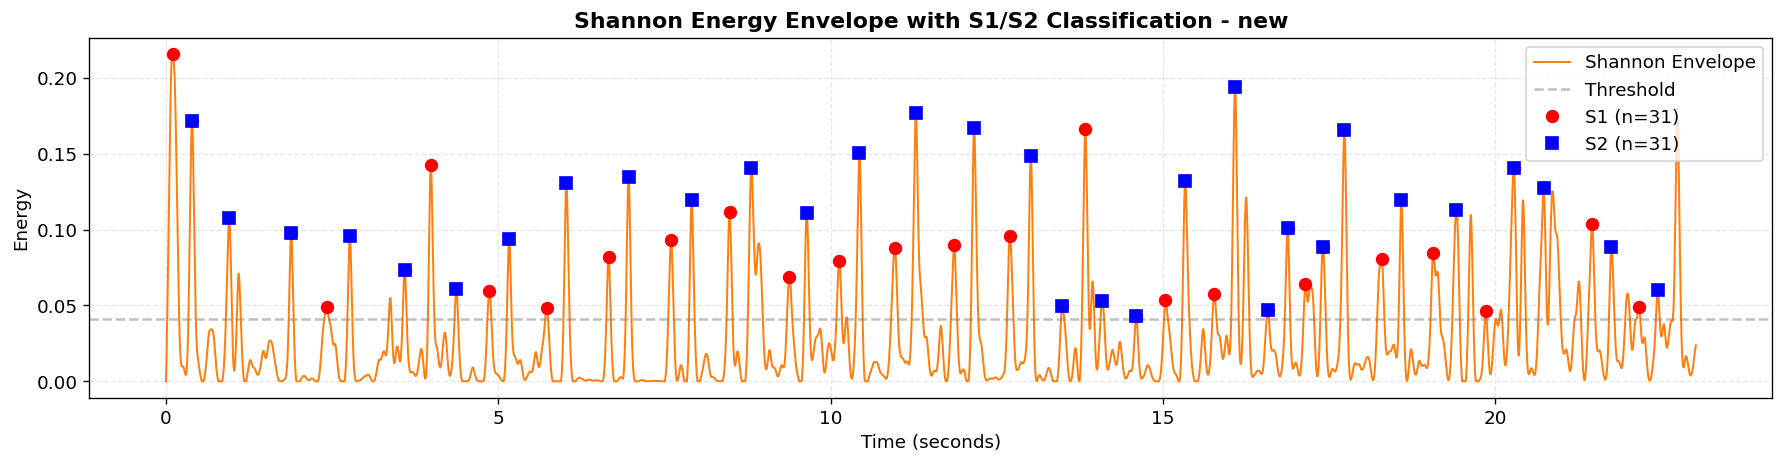

In [14]:
# Plot envelope with S1/S2 markers
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(time_axis, envelope, color='#ff7f0e', lw=1.2, label='Shannon Envelope')
ax.axhline(y=threshold, color='gray', ls='--', alpha=0.5, label='Threshold')
if len(s1_peaks):
    ax.plot(s1_peaks/sample_rate, envelope[s1_peaks], 'o', color='red', ms=7,
            label=f'S1 (n={len(s1_peaks)})', zorder=5)
if len(s2_peaks):
    ax.plot(s2_peaks/sample_rate, envelope[s2_peaks], 's', color='blue', ms=7,
            label=f'S2 (n={len(s2_peaks)})', zorder=5)

ax.set_title('Shannon Energy Envelope with S1/S2 Classification - new', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Energy')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## Module 1: Heart Sound Segmentation

Segments the signal into four cardiac phases per cycle:  
**S1 → Systole → S2 → Diastole → S1 → ...**

Uses envelope width at 40% of peak height to estimate S1/S2 boundaries,  
then fills systole and diastole in the gaps.

In [11]:
def estimate_sound_width(envelope, peak_idx, sr, max_width_s=0.15):
    """Find heart sound boundaries at 40% of peak height."""
    half_height = envelope[peak_idx] * 0.4
    max_w = int(sr * max_width_s)

    left = peak_idx
    for j in range(peak_idx, max(0, peak_idx - max_w), -1):
        if envelope[j] < half_height:
            left = j
            break

    right = peak_idx
    for j in range(peak_idx, min(len(envelope), peak_idx + max_w)):
        if envelope[j] < half_height:
            right = j
            break

    return left, right


def segment_heart_sounds(filtered, envelope, s1_peaks, s2_peaks, sr):
    """Create per-sample state labels: 0=S1, 1=Systole, 2=S2, 3=Diastole"""
    n = len(filtered)
    states = np.full(n, 3, dtype=int)  # default = diastole

    s1_bounds = []
    for pk in s1_peaks:
        left, right = estimate_sound_width(envelope, pk, sr, 0.08)
        states[left:right] = 0
        s1_bounds.append((left, right))

    s2_bounds = []
    for pk in s2_peaks:
        left, right = estimate_sound_width(envelope, pk, sr, 0.07)
        states[left:right] = 2
        s2_bounds.append((left, right))

    # Systole = between S1_end and next S2_start
    for _, s1_end in s1_bounds:
        next_s2 = [s2_l for s2_l, _ in s2_bounds if s2_l > s1_end]
        if next_s2 and (next_s2[0] - s1_end) / sr < 0.40:
            states[s1_end:next_s2[0]] = 1

    # Diastole = between S2_end and next S1_start
    for _, s2_end in s2_bounds:
        next_s1 = [s1_l for s1_l, _ in s1_bounds if s1_l > s2_end]
        if next_s1:
            states[s2_end:next_s1[0]] = 3

    # Build segment list
    state_names = ['S1', 'Systole', 'S2', 'Diastole']
    segments = []
    i = 0
    while i < n:
        j = i
        while j < n and states[j] == states[i]:
            j += 1
        segments.append((state_names[states[i]], i, j))
        i = j

    return states, segments

print("✓ Segmentation functions defined")

✓ Segmentation functions defined


In [12]:
# Run segmentation
states, segments = segment_heart_sounds(filtered, envelope, s1_peaks, s2_peaks, sample_rate)

# Report
STATE_NAMES = ['S1', 'Systole', 'S2', 'Diastole']
print("Segmentation Results")
print("=" * 60)
for sn in STATE_NAMES:
    durs = [(e - s) / sample_rate * 1000 for name, s, e in segments if name == sn]
    if durs:
        print(f"  {sn:10s}: {len(durs):3d} segments | "
              f"{np.mean(durs):6.1f} ± {np.std(durs):5.1f} ms "
              f"[{np.min(durs):.0f}–{np.max(durs):.0f}]")

Segmentation Results
  S1        :  20 segments |   88.4 ±  26.2 ms [46–128]
  Systole   :  22 segments |  231.8 ±  41.9 ms [154–314]
  S2        :  28 segments |   85.3 ±  16.5 ms [48–114]
  Diastole  :  29 segments |  474.6 ± 257.2 ms [34–1410]


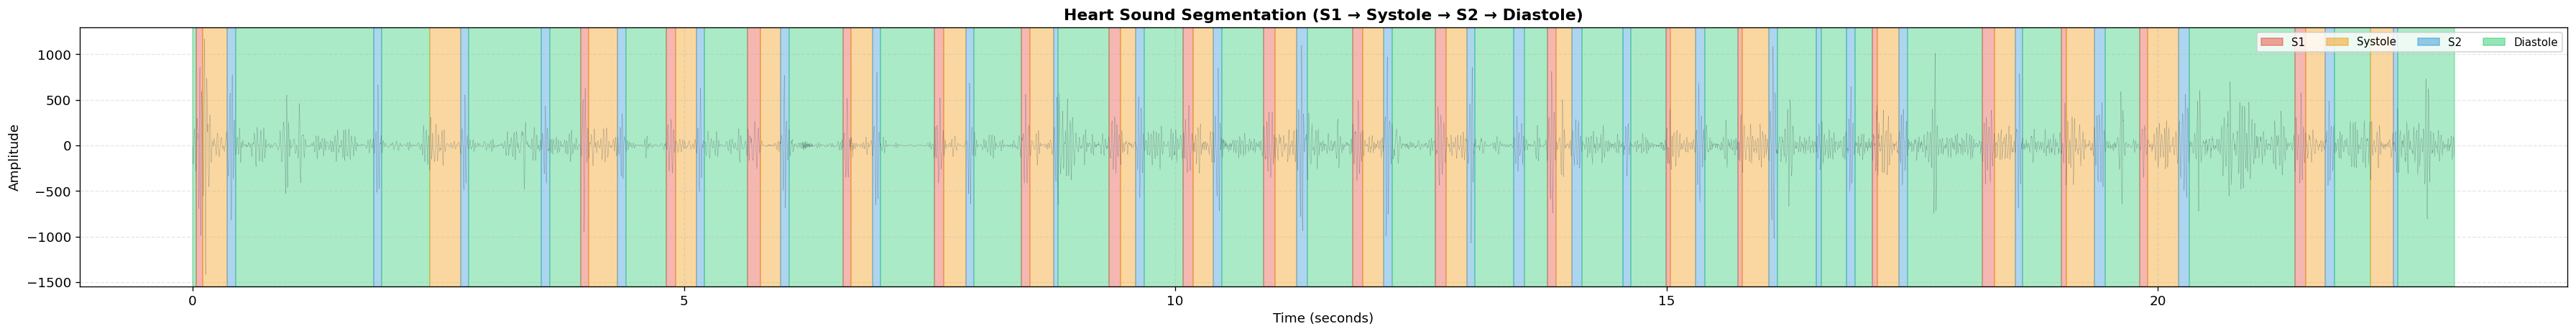

In [16]:
# Full recording segmentation view
STATE_COLORS = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(30, 4))
ax.plot(time_axis, filtered, color='#2c3e50', lw=0.3, alpha=0.4)
for sn, s, e in segments:
    idx = STATE_NAMES.index(sn)
    ax.axvspan(s/sample_rate, e/sample_rate, alpha=0.4, color=STATE_COLORS[idx])

patches = [mpatches.Patch(color=c, alpha=0.5, label=nm)
           for nm, c in zip(STATE_NAMES, STATE_COLORS)]
ax.legend(handles=patches, loc='upper right', fontsize=9, ncol=4)
ax.set_title('Heart Sound Segmentation (S1 → Systole → S2 → Diastole)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

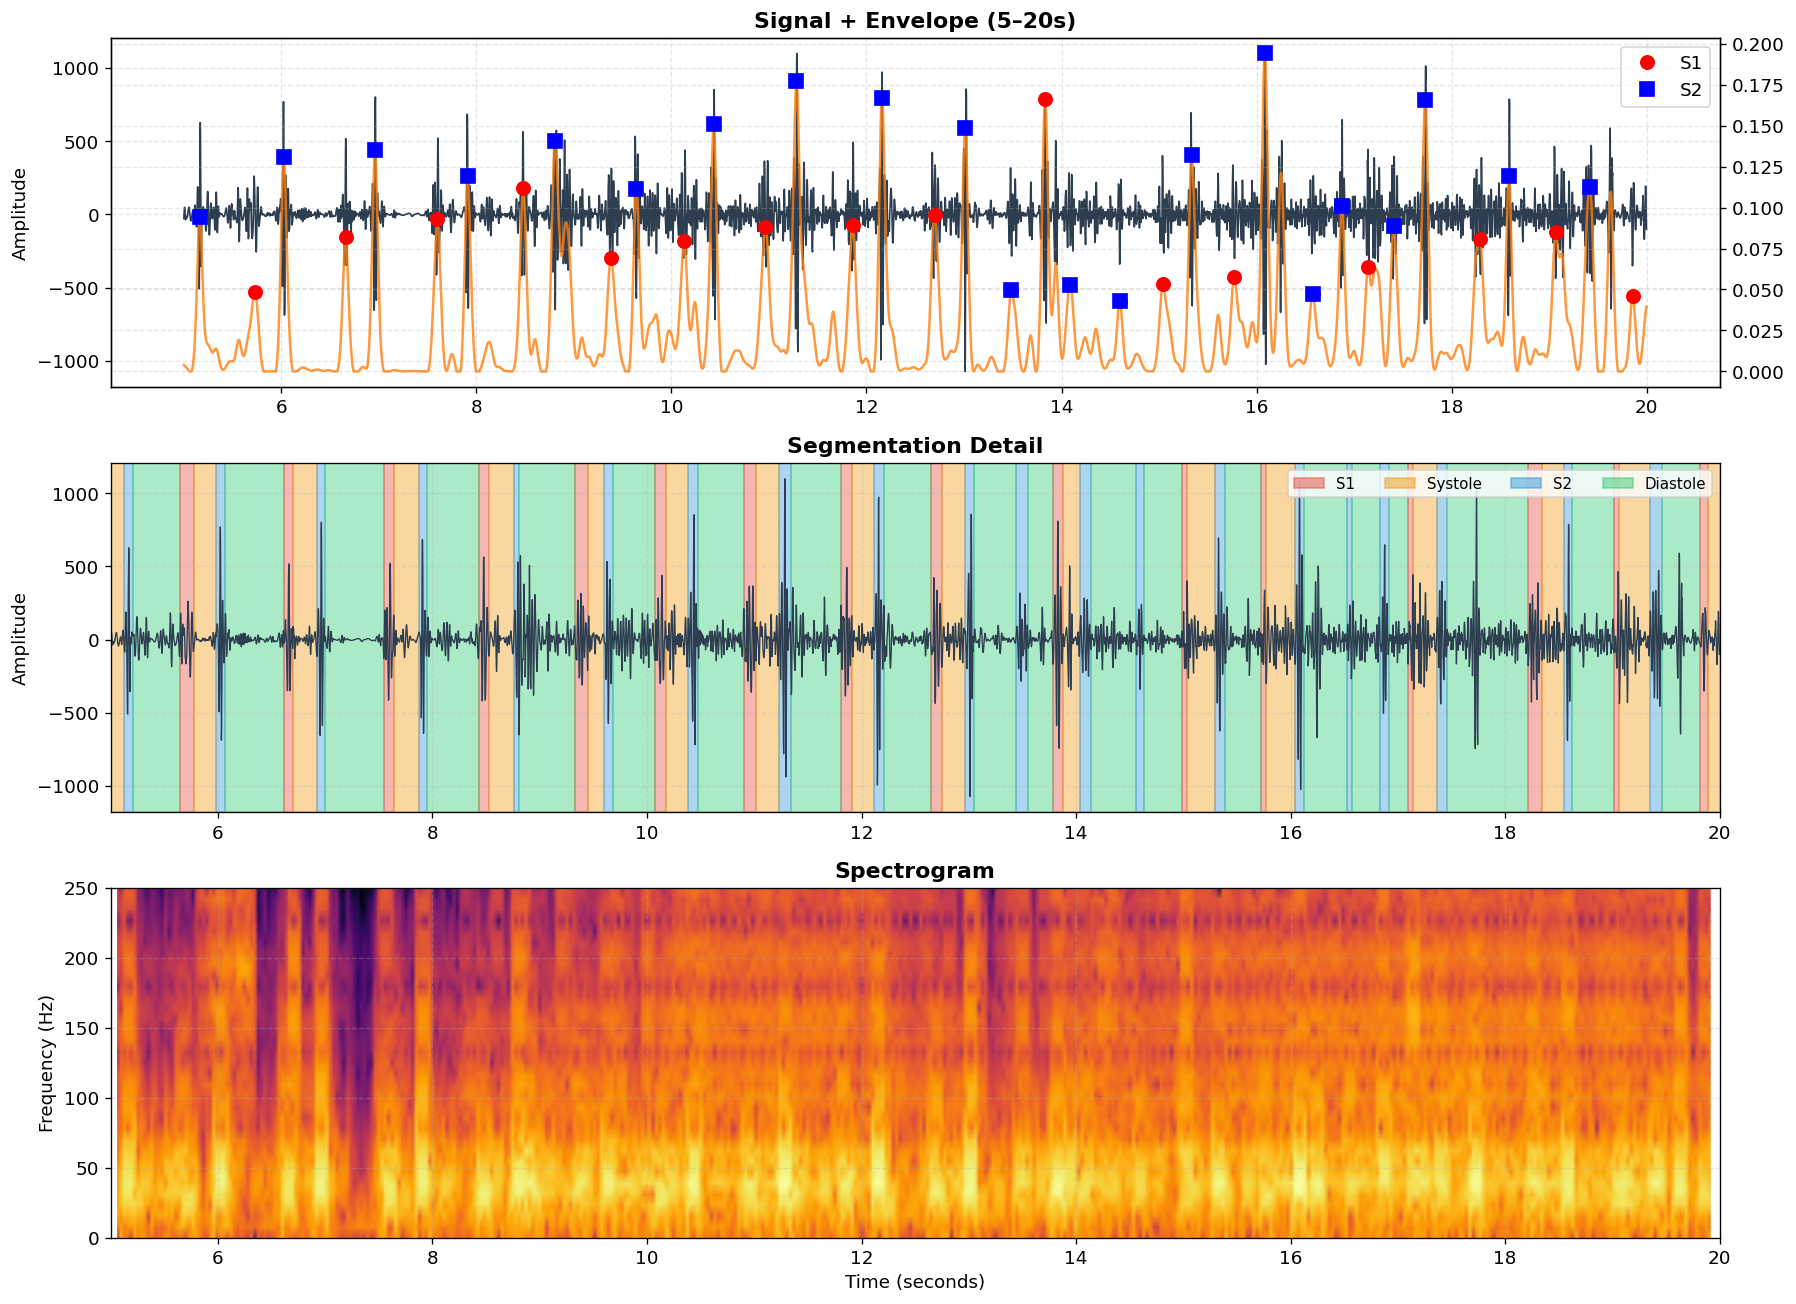

In [17]:
# Zoomed detail view — change ZOOM_START / ZOOM_END to explore different regions
ZOOM_START = 5.0   # seconds
ZOOM_END   = 20.0  # seconds

mask = (time_axis >= ZOOM_START) & (time_axis < ZOOM_END)

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# Signal + envelope
axes[0].plot(time_axis[mask], filtered[mask], color='#2c3e50', lw=1)
ax0t = axes[0].twinx()
ax0t.plot(time_axis[mask], envelope[mask], color='#ff7f0e', lw=1.5, alpha=0.8)
zs1 = s1_peaks[(s1_peaks/sample_rate >= ZOOM_START) & (s1_peaks/sample_rate < ZOOM_END)]
zs2 = s2_peaks[(s2_peaks/sample_rate >= ZOOM_START) & (s2_peaks/sample_rate < ZOOM_END)]
if len(zs1): ax0t.plot(zs1/sample_rate, envelope[zs1], 'o', color='red', ms=8, label='S1')
if len(zs2): ax0t.plot(zs2/sample_rate, envelope[zs2], 's', color='blue', ms=8, label='S2')
ax0t.legend(loc='upper right')
axes[0].set_title(f'Signal + Envelope ({ZOOM_START:.0f}–{ZOOM_END:.0f}s)', fontweight='bold')
axes[0].set_ylabel('Amplitude')

# Segmentation
axes[1].plot(time_axis[mask], filtered[mask], color='#2c3e50', lw=0.8)
for sn, s, e in segments:
    if e/sample_rate >= ZOOM_START and s/sample_rate <= ZOOM_END:
        idx = STATE_NAMES.index(sn)
        axes[1].axvspan(max(s/sample_rate, ZOOM_START), min(e/sample_rate, ZOOM_END),
                       alpha=0.4, color=STATE_COLORS[idx])
axes[1].legend(handles=patches, loc='upper right', fontsize=9, ncol=4)
axes[1].set_title('Segmentation Detail', fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim(ZOOM_START, ZOOM_END)

# Spectrogram
zsig = filtered[mask]
nperseg = min(64, len(zsig) // 4)
if nperseg > 8:
    f_, t_, S_ = spectrogram(zsig, fs=sample_rate, nperseg=nperseg, noverlap=nperseg*3//4)
    axes[2].pcolormesh(t_ + ZOOM_START, f_, 10*np.log10(S_ + 1e-10),
                       shading='gouraud', cmap='inferno')
axes[2].set_title('Spectrogram', fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_ylim(0, nyq)
axes[2].set_xlim(ZOOM_START, ZOOM_END)

plt.tight_layout()
plt.show()

---
## Module 2: Normal vs. Abnormal Classification

Two approaches:
1. **Rule-based screening** — checks each cycle against physiological normal ranges
2. **Anomaly detection** — Isolation Forest on per-cycle feature vectors (flags statistical outliers)

In [ ]:
# Helper functions
def spectral_centroid(x, sr):
    if len(x) < 8: return 0
    mag = np.abs(np.fft.rfft(x))
    freqs = np.fft.rfftfreq(len(x), 1.0 / sr)
    return np.sum(freqs * mag) / (np.sum(mag) + 1e-10)

def zero_crossing_rate(x):
    if len(x) < 2: return 0
    return np.sum(np.diff(np.sign(x)) != 0) / len(x)

def excess_kurtosis(x):
    if len(x) < 4: return 0
    m, s = np.mean(x), np.std(x)
    if s < 1e-10: return 0
    return np.mean(((x - m) / s) ** 4) - 3


def extract_cycle_features(filtered, segments, sr):
    """Extract features for each complete S1→Systole→S2→Diastole cycle."""
    cycles = []
    i = 0
    while i + 3 < len(segments):
        if (segments[i][0] == 'S1' and segments[i+1][0] == 'Systole' and
            segments[i+2][0] == 'S2' and segments[i+3][0] == 'Diastole'):

            s1_start, s1_end = segments[i][1], segments[i][2]
            sys_start, sys_end = segments[i+1][1], segments[i+1][2]
            s2_start, s2_end = segments[i+2][1], segments[i+2][2]
            dia_start, dia_end = segments[i+3][1], segments[i+3][2]

            s1_sig = filtered[s1_start:s1_end]
            sys_sig = filtered[sys_start:sys_end]
            s2_sig = filtered[s2_start:s2_end]
            dia_sig = filtered[dia_start:dia_end]
            full = filtered[s1_start:dia_end]

            if len(s1_sig) < 3 or len(s2_sig) < 3 or len(full) < 10:
                i += 1
                continue

            s1_rms = np.sqrt(np.mean(s1_sig**2))
            s2_rms = np.sqrt(np.mean(s2_sig**2))
            sys_rms = np.sqrt(np.mean(sys_sig**2)) if len(sys_sig) > 0 else 0
            dia_rms = np.sqrt(np.mean(dia_sig**2)) if len(dia_sig) > 0 else 0

            s1_dur = len(s1_sig) / sr * 1000
            s2_dur = len(s2_sig) / sr * 1000
            systolic = (s2_start - s1_start) / sr * 1000
            diastolic = (dia_end - s2_start) / sr * 1000
            cycle_dur = (dia_end - s1_start) / sr * 1000
            hr = 60000.0 / cycle_dur if cycle_dur > 0 else 0

            nfft = min(64, len(full))
            if nfft >= 16:
                mfccs = librosa.feature.mfcc(y=full, sr=sr, n_mfcc=8, n_fft=nfft)
                mfcc_means = np.mean(mfccs, axis=1)
            else:
                mfcc_means = np.zeros(8)

            cycle = {
                's1_duration_ms': s1_dur, 's2_duration_ms': s2_dur,
                'systolic_ms': systolic, 'diastolic_ms': diastolic,
                'cycle_duration_ms': cycle_dur, 'heart_rate_bpm': hr,
                'sd_ratio': systolic / (diastolic + 1e-10),
                's1_rms': s1_rms, 's2_rms': s2_rms,
                's1_s2_amp_ratio': s1_rms / (s2_rms + 1e-10),
                'energy_concentration': (np.sum(s1_sig**2) + np.sum(s2_sig**2)) / (np.sum(full**2) + 1e-10),
                's1_zcr': zero_crossing_rate(s1_sig), 's2_zcr': zero_crossing_rate(s2_sig),
                's1_kurtosis': excess_kurtosis(s1_sig), 's2_kurtosis': excess_kurtosis(s2_sig),
                's1_centroid': spectral_centroid(s1_sig, sr),
                's2_centroid': spectral_centroid(s2_sig, sr),
                'sys_noise_ratio': sys_rms / (s1_rms + 1e-10),
                'dia_noise_ratio': dia_rms / (s1_rms + 1e-10),
                **{f'mfcc_{j}': v for j, v in enumerate(mfcc_means)},
                '_s1_start': s1_start, '_s1_end': s1_end,
                '_sys_start': sys_start, '_sys_end': sys_end,
                '_s2_start': s2_start, '_s2_end': s2_end,
                '_dia_start': dia_start, '_dia_end': dia_end,
            }
            cycles.append(cycle)
            i += 4
        else:
            i += 1
    return cycles

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


In [ ]:
# Extract per-cycle features
cycles = extract_cycle_features(filtered, segments, sample_rate)
print(f"Complete cardiac cycles found: {len(cycles)}")

Complete cardiac cycles found: 28


In [ ]:
# ── Rule-based screening ──
flagged = []
for ci, c in enumerate(cycles):
    violations = []
    for key, (lo, hi) in NORMAL_RANGES.items():
        if key in c:
            v = c[key]
            if v < lo: violations.append(f"{key}={v:.1f} < {lo}")
            elif v > hi: violations.append(f"{key}={v:.1f} > {hi}")
    if violations:
        flagged.append((ci, violations))

print("Rule-Based Screening")
print("=" * 50)
print(f"  Normal cycles:  {len(cycles) - len(flagged)} / {len(cycles)}")
print(f"  Flagged cycles: {len(flagged)} / {len(cycles)}")
if flagged:
    print("\n  Flagged details:")
    for idx, vs in flagged[:5]:
        print(f"    Cycle {idx}: {'; '.join(vs)}")

Rule-Based Screening
  Normal cycles:  20 / 28
  Flagged cycles: 8 / 28

  Flagged details:
    Cycle 0: s1_s2_amp_ratio=0.5 < 0.5
    Cycle 5: s1_s2_amp_ratio=0.4 < 0.5
    Cycle 11: s1_s2_amp_ratio=0.4 < 0.5
    Cycle 13: s1_s2_amp_ratio=0.5 < 0.5
    Cycle 15: s1_s2_amp_ratio=0.5 < 0.5


In [ ]:
# ── Anomaly detection (Isolation Forest) ──
feat_keys = [k for k in cycles[0] if not k.startswith('_')]
X = np.array([[c[k] for k in feat_keys] for c in cycles])
X = np.nan_to_num(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(contamination=0.15, random_state=42, n_estimators=200)
labels = iso_forest.fit_predict(X_scaled)
scores = iso_forest.decision_function(X_scaled)

print("Anomaly Detection (Isolation Forest)")
print("=" * 50)
print(f"  Normal cycles:  {np.sum(labels == 1)} / {len(cycles)}")
print(f"  Anomaly cycles: {np.sum(labels == -1)} / {len(cycles)}")
print(f"  Score range:    [{scores.min():.3f}, {scores.max():.3f}]")

Anomaly Detection (Isolation Forest)
  Normal cycles:  23 / 28
  Anomaly cycles: 5 / 28
  Score range:    [-0.053, 0.100]


In [ ]:
# ── Per-cycle statistics ──
print("Per-Cycle Statistics")
print("=" * 70)
for key in ['heart_rate_bpm', 's1_duration_ms', 's2_duration_ms',
            'systolic_ms', 'diastolic_ms', 's1_s2_amp_ratio', 'sd_ratio']:
    vals = np.array([c[key] for c in cycles])
    print(f"  {key:25s}: {np.mean(vals):8.1f} ± {np.std(vals):6.1f}  "
          f"[{np.min(vals):7.1f} – {np.max(vals):7.1f}]")

# HRV metrics
rr = np.array([c['cycle_duration_ms'] for c in cycles])
valid_rr = rr[(rr > 300) & (rr < 1500)]
if len(valid_rr) > 2:
    sdnn = np.std(valid_rr)
    rmssd = np.sqrt(np.mean(np.diff(valid_rr)**2))
    nn50 = np.sum(np.abs(np.diff(valid_rr)) > 50)
    pnn50 = 100 * nn50 / len(valid_rr)
    hr_vals = 60000 / valid_rr
    print(f"\nHRV Metrics")
    print(f"{'─' * 40}")
    print(f"  Heart Rate: {np.mean(hr_vals):.1f} ± {np.std(hr_vals):.1f} BPM")
    print(f"  SDNN:       {sdnn:.1f} ms  (overall variability)")
    print(f"  RMSSD:      {rmssd:.1f} ms  (short-term variability)")
    print(f"  pNN50:      {pnn50:.1f} %   (parasympathetic indicator)")

Per-Cycle Statistics
  heart_rate_bpm           :     73.2 ±    4.3  [   55.7 –    78.7]
  s1_duration_ms           :     98.9 ±    9.8  [   86.0 –   120.0]
  s2_duration_ms           :     82.7 ±    2.2  [   80.0 –    88.0]
  systolic_ms              :    302.4 ±   10.1  [  284.0 –   330.0]
  diastolic_ms             :    520.9 ±   54.2  [  460.0 –   764.0]
  s1_s2_amp_ratio          :      0.6 ±    0.1  [    0.4 –     0.9]
  sd_ratio                 :      0.6 ±    0.0  [    0.4 –     0.7]

HRV Metrics
────────────────────────────────────────
  Heart Rate: 73.2 ± 4.3 BPM
  SDNN:       57.5 ms  (overall variability)
  RMSSD:      88.6 ms  (short-term variability)
  pNN50:      35.7 %   (parasympathetic indicator)


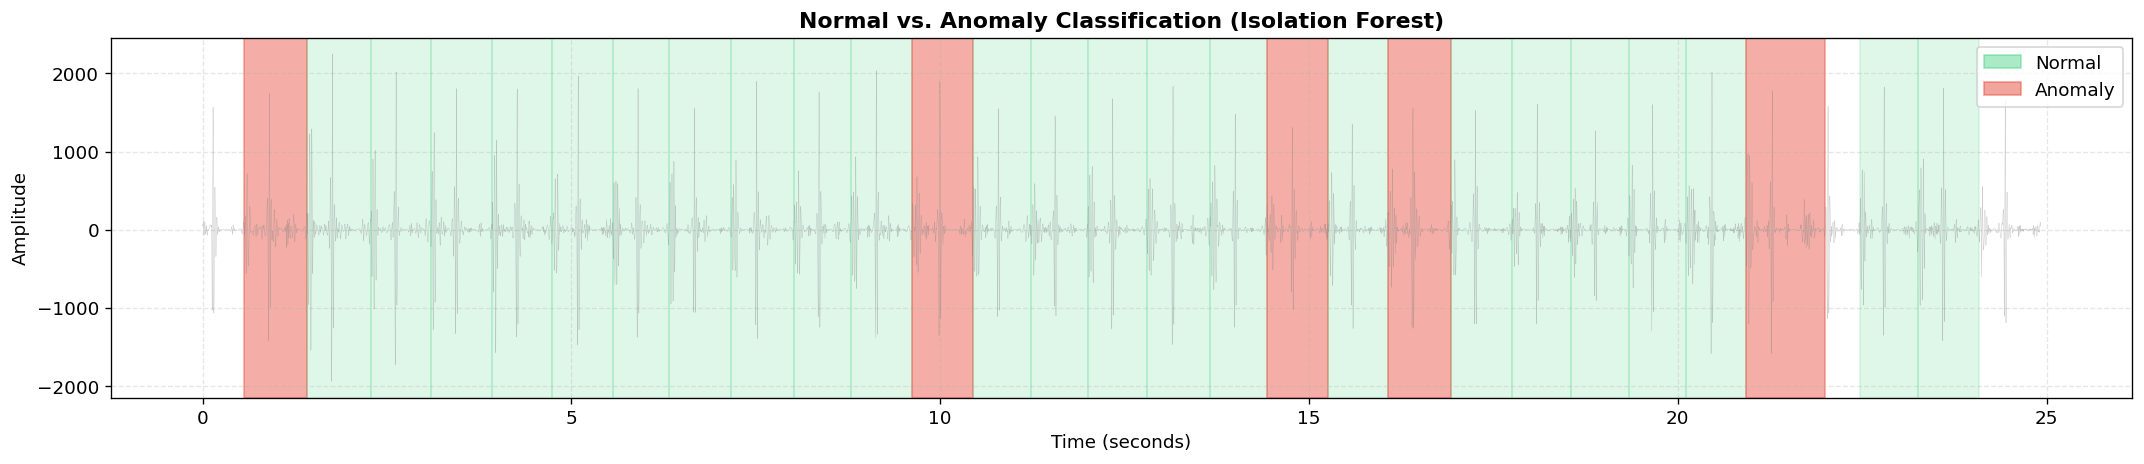

In [ ]:
# Classification plot
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(time_axis, filtered, color='gray', lw=0.3, alpha=0.4)
for c, lab in zip(cycles, labels):
    color = '#2ecc71' if lab == 1 else '#e74c3c'
    alpha = 0.15 if lab == 1 else 0.45
    ax.axvspan(c['_s1_start']/sample_rate, c['_dia_end']/sample_rate,
               alpha=alpha, color=color)

np_ = mpatches.Patch(color='#2ecc71', alpha=0.4, label='Normal')
ap_ = mpatches.Patch(color='#e74c3c', alpha=0.5, label='Anomaly')
ax.legend(handles=[np_, ap_], loc='upper right')
ax.set_title('Normal vs. Anomaly Classification (Isolation Forest)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

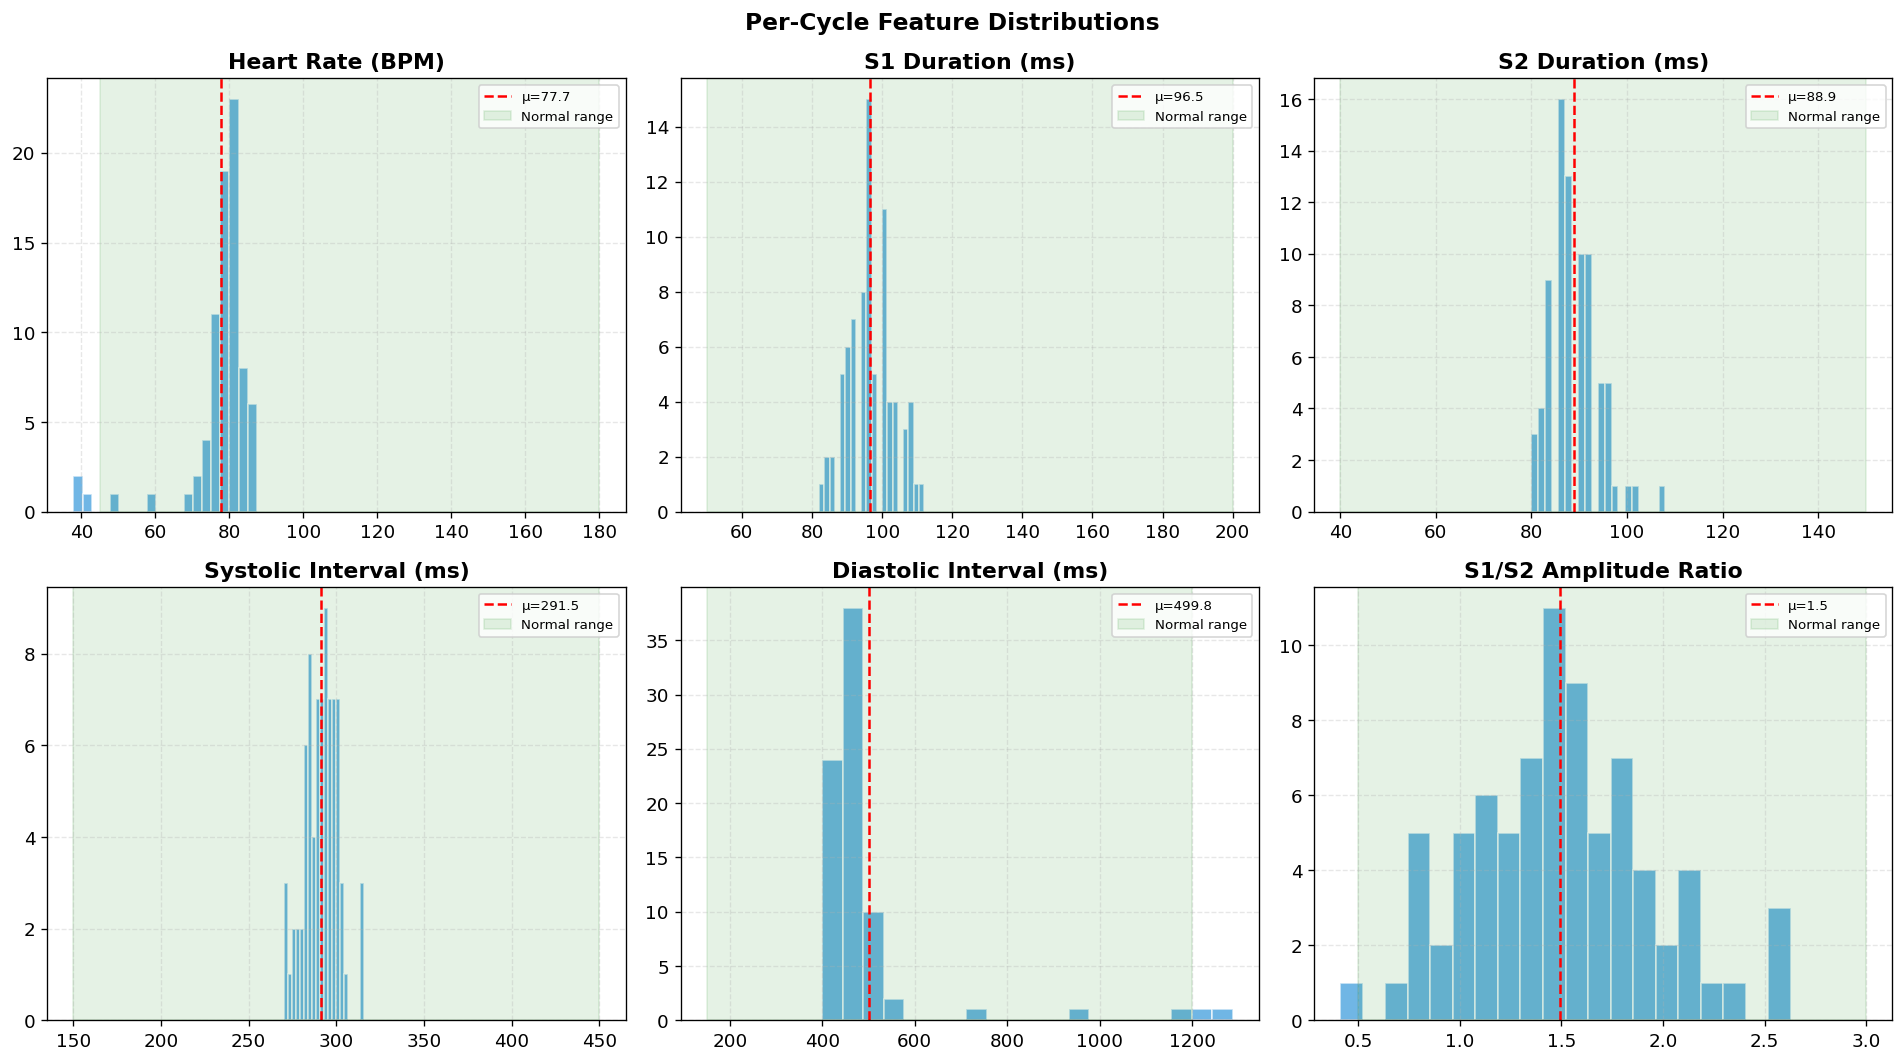

In [ ]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
feat_plots = [
    ('heart_rate_bpm', 'Heart Rate (BPM)'),
    ('s1_duration_ms', 'S1 Duration (ms)'),
    ('s2_duration_ms', 'S2 Duration (ms)'),
    ('systolic_ms', 'Systolic Interval (ms)'),
    ('diastolic_ms', 'Diastolic Interval (ms)'),
    ('s1_s2_amp_ratio', 'S1/S2 Amplitude Ratio'),
]
for ax, (key, title) in zip(axes.flat, feat_plots):
    vals = [c[key] for c in cycles]
    ax.hist(vals, bins=20, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(vals), color='red', ls='--', lw=1.5, label=f'μ={np.mean(vals):.1f}')
    if key in NORMAL_RANGES:
        lo, hi = NORMAL_RANGES[key]
        ax.axvspan(lo, hi, alpha=0.1, color='green', label='Normal range')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Per-Cycle Feature Distributions', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## Module 3: Murmur Detection & Grading

Analyzes energy during systolic and diastolic intervals.  
Normal hearts have near-silence between S1 and S2. Murmurs appear as sustained sound.

**Detectable at 250 Hz Nyquist:**
- Aortic stenosis (80–200 Hz, diamond-shaped systolic murmur)
- Mitral regurgitation components (100–200 Hz)
- Timing classification (systolic vs diastolic)

**Grading (Levine scale adaptation):**

| Grade | Description | Noise Ratio |
|-------|-------------|-------------|
| 0 | None | < 0.15 |
| 1 | Barely detectable | 0.15–0.30 |
| 2 | Faint but clear | 0.30–0.50 |
| 3 | Moderately loud | 0.50–0.70 |
| 4 | Loud | 0.70–0.90 |
| 5–6 | Very loud | > 0.90 |

In [ ]:
def murmur_grade(ratio):
    """Convert energy ratio to Levine-style grade (0–6)."""
    for i, th in enumerate(MURMUR_GRADE_THRESHOLDS):
        if ratio < th: return i
    return 6


def detect_murmur(filtered, cycle, sr):
    """Analyze one cardiac cycle for murmur presence."""
    sys_sig = filtered[cycle['_sys_start']:cycle['_sys_end']]
    dia_sig = filtered[cycle['_dia_start']:cycle['_dia_end']]
    s1_rms = cycle['s1_rms']

    result = {
        'systolic_murmur': False, 'diastolic_murmur': False,
        'systolic_grade': 0, 'diastolic_grade': 0,
        'systolic_ratio': 0, 'diastolic_ratio': 0,
    }

    if len(sys_sig) > 4:
        r = np.sqrt(np.mean(sys_sig**2)) / (s1_rms + 1e-10)
        result['systolic_ratio'] = r
        result['systolic_grade'] = murmur_grade(r)
        result['systolic_murmur'] = r > MURMUR_GRADE_THRESHOLDS[0]
        if len(sys_sig) > 15:
            env = uniform_filter1d(np.abs(hilbert(sys_sig)), max(3, len(sys_sig)//5))
            pk_pos = np.argmax(env) / len(env)
            result['sys_diamond'] = 0.25 < pk_pos < 0.75

    if len(dia_sig) > 4:
        r = np.sqrt(np.mean(dia_sig**2)) / (s1_rms + 1e-10)
        result['diastolic_ratio'] = r
        result['diastolic_grade'] = murmur_grade(r)
        result['diastolic_murmur'] = r > MURMUR_GRADE_THRESHOLDS[0]
        if len(dia_sig) > 15:
            env = uniform_filter1d(np.abs(hilbert(dia_sig)), max(3, len(dia_sig)//5))
            q1 = np.mean(env[:len(env)//4])
            q4 = np.mean(env[3*len(env)//4:])
            result['dia_decrescendo'] = q1 > 1.5 * q4 if q4 > 0 else False

    return result

print("✓ Murmur detection functions defined")

✓ Murmur detection functions defined


In [ ]:
# Run murmur detection on all cycles
murmur_results = [detect_murmur(filtered, c, sample_rate) for c in cycles]

sys_m = sum(1 for r in murmur_results if r['systolic_murmur'])
dia_m = sum(1 for r in murmur_results if r['diastolic_murmur'])
total = len(murmur_results)

print("Murmur Detection Results")
print("=" * 55)
print(f"  Analysis range: 0–{nyq:.0f} Hz (limited by {sample_rate} Hz sample rate)")

print(f"\n  Systolic murmur:  {sys_m}/{total} cycles ({100*sys_m/total:.0f}%)")
if sys_m > 0:
    sr_v = [r['systolic_ratio'] for r in murmur_results if r['systolic_murmur']]
    sg_v = [r['systolic_grade'] for r in murmur_results if r['systolic_murmur']]
    print(f"    Avg noise ratio: {np.mean(sr_v):.3f} | Avg grade: {np.mean(sg_v):.1f}/6")
    diamonds = sum(1 for r in murmur_results if r.get('sys_diamond', False))
    if diamonds:
        print(f"    Diamond shape: {diamonds} cycles → possible ejection murmur")

print(f"\n  Diastolic murmur: {dia_m}/{total} cycles ({100*dia_m/total:.0f}%)")
if dia_m > 0:
    dr_v = [r['diastolic_ratio'] for r in murmur_results if r['diastolic_murmur']]
    dg_v = [r['diastolic_grade'] for r in murmur_results if r['diastolic_murmur']]
    print(f"    Avg noise ratio: {np.mean(dr_v):.3f} | Avg grade: {np.mean(dg_v):.1f}/6")

# Assessment
sys_pct = 100 * sys_m / total
dia_pct = 100 * dia_m / total
print(f"\n  {'─' * 40}")
if sys_pct > 50 or dia_pct > 50:
    print(f"  ⚠ Significant murmur activity (Sys: {sys_pct:.0f}%, Dia: {dia_pct:.0f}%)")
elif sys_pct > 20 or dia_pct > 20:
    print(f"  ℹ Some murmur-like activity detected (may be recording noise)")
else:
    print(f"  ✓ No significant murmur activity")

print(f"\n  ⚕ This is a signal analysis tool, NOT a medical diagnostic device.")

Murmur Detection Results
  Analysis range: 0–250 Hz (limited by 500 Hz sample rate)

  Systolic murmur:  7/28 cycles (25%)
    Avg noise ratio: 0.191 | Avg grade: 1.0/6
    Diamond shape: 3 cycles → possible ejection murmur

  Diastolic murmur: 8/28 cycles (29%)
    Avg noise ratio: 0.189 | Avg grade: 1.0/6

  ────────────────────────────────────────
  ℹ Some murmur-like activity detected (may be recording noise)

  ⚕ This is a signal analysis tool, NOT a medical diagnostic device.


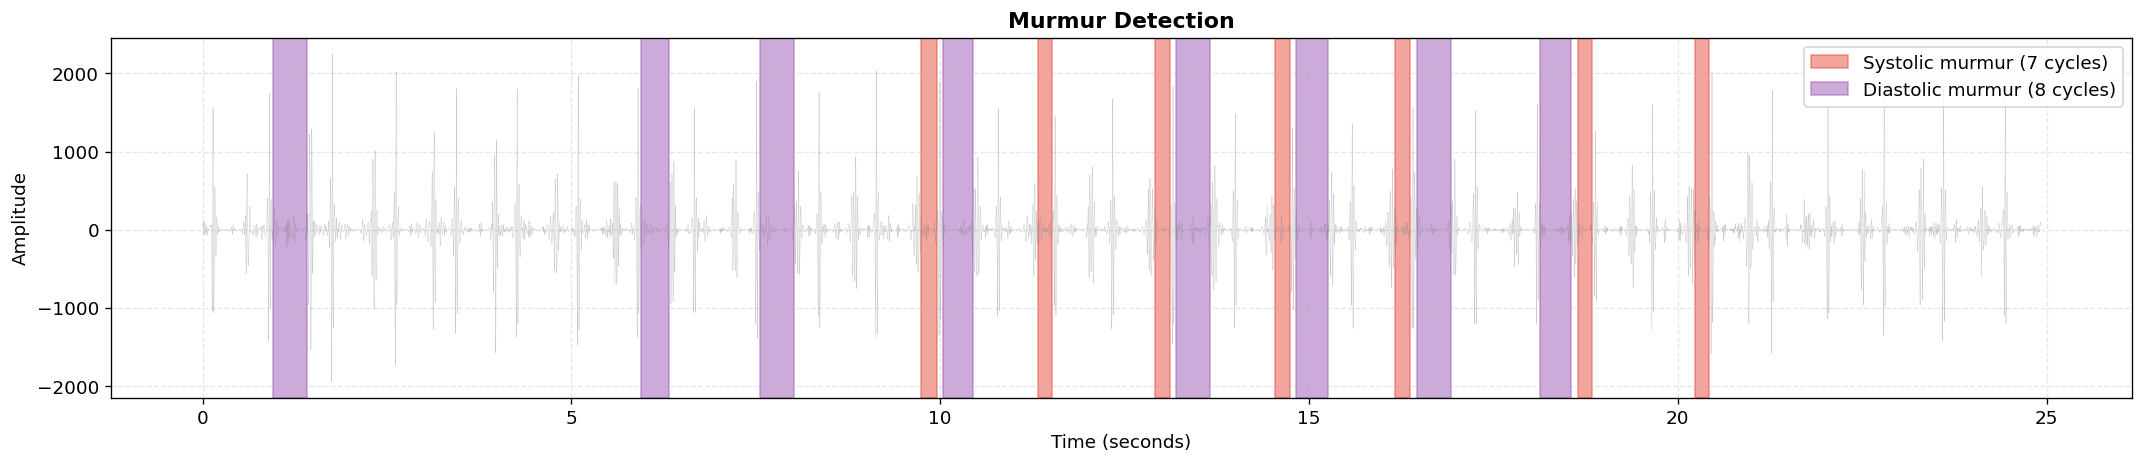

In [ ]:
# Murmur detection visualization
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(time_axis, filtered, color='gray', lw=0.3, alpha=0.4)

for c, mr in zip(cycles, murmur_results):
    if mr['systolic_murmur']:
        ax.axvspan(c['_sys_start']/sample_rate, c['_sys_end']/sample_rate,
                   alpha=0.5, color='#e74c3c')
    if mr['diastolic_murmur']:
        ax.axvspan(c['_dia_start']/sample_rate, c['_dia_end']/sample_rate,
                   alpha=0.5, color='#9b59b6')

sp_ = mpatches.Patch(color='#e74c3c', alpha=0.5, label=f'Systolic murmur ({sys_m} cycles)')
dp_ = mpatches.Patch(color='#9b59b6', alpha=0.5, label=f'Diastolic murmur ({dia_m} cycles)')
ax.legend(handles=[sp_, dp_], loc='upper right')
ax.set_title('Murmur Detection', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

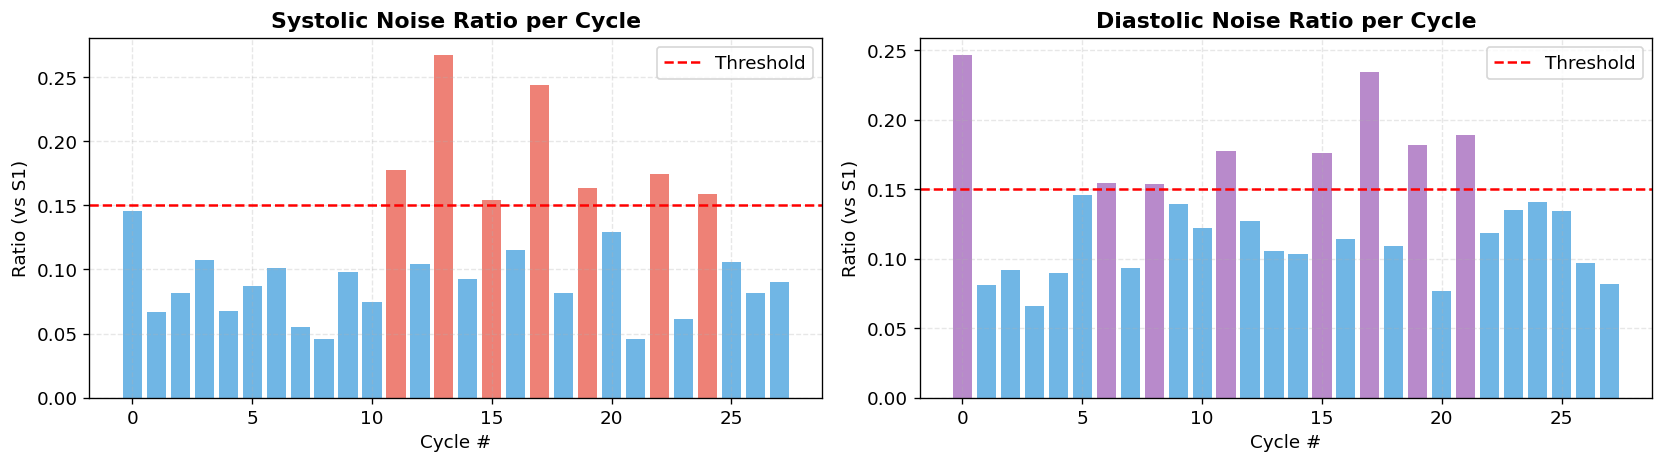

In [ ]:
# Per-cycle murmur ratios
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sys_ratios = [r['systolic_ratio'] for r in murmur_results]
dia_ratios = [r['diastolic_ratio'] for r in murmur_results]

axes[0].bar(range(len(sys_ratios)), sys_ratios,
            color=['#e74c3c' if r > MURMUR_GRADE_THRESHOLDS[0] else '#3498db' for r in sys_ratios],
            alpha=0.7)
axes[0].axhline(y=MURMUR_GRADE_THRESHOLDS[0], color='red', ls='--', label='Threshold')
axes[0].set_title('Systolic Noise Ratio per Cycle', fontweight='bold')
axes[0].set_xlabel('Cycle #')
axes[0].set_ylabel('Ratio (vs S1)')
axes[0].legend()

axes[1].bar(range(len(dia_ratios)), dia_ratios,
            color=['#9b59b6' if r > MURMUR_GRADE_THRESHOLDS[0] else '#3498db' for r in dia_ratios],
            alpha=0.7)
axes[1].axhline(y=MURMUR_GRADE_THRESHOLDS[0], color='red', ls='--', label='Threshold')
axes[1].set_title('Diastolic Noise Ratio per Cycle', fontweight='bold')
axes[1].set_xlabel('Cycle #')
axes[1].set_ylabel('Ratio (vs S1)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Export Filtered WAV

In [ ]:
# Save filtered signal as WAV
output_filename = FILENAME.replace('.wav', '_filtered.wav')
f_norm = filtered / (np.max(np.abs(filtered)) + 1e-10)
wav_write(output_filename, sample_rate, (f_norm * 32767).astype(np.int16))

print(f"✓ Saved: {output_filename}")

# Listen to filtered signal
Audio(data=f_norm, rate=sample_rate)

✓ Saved: aman4-ble_filtered.wav


---
## Summary Dashboard

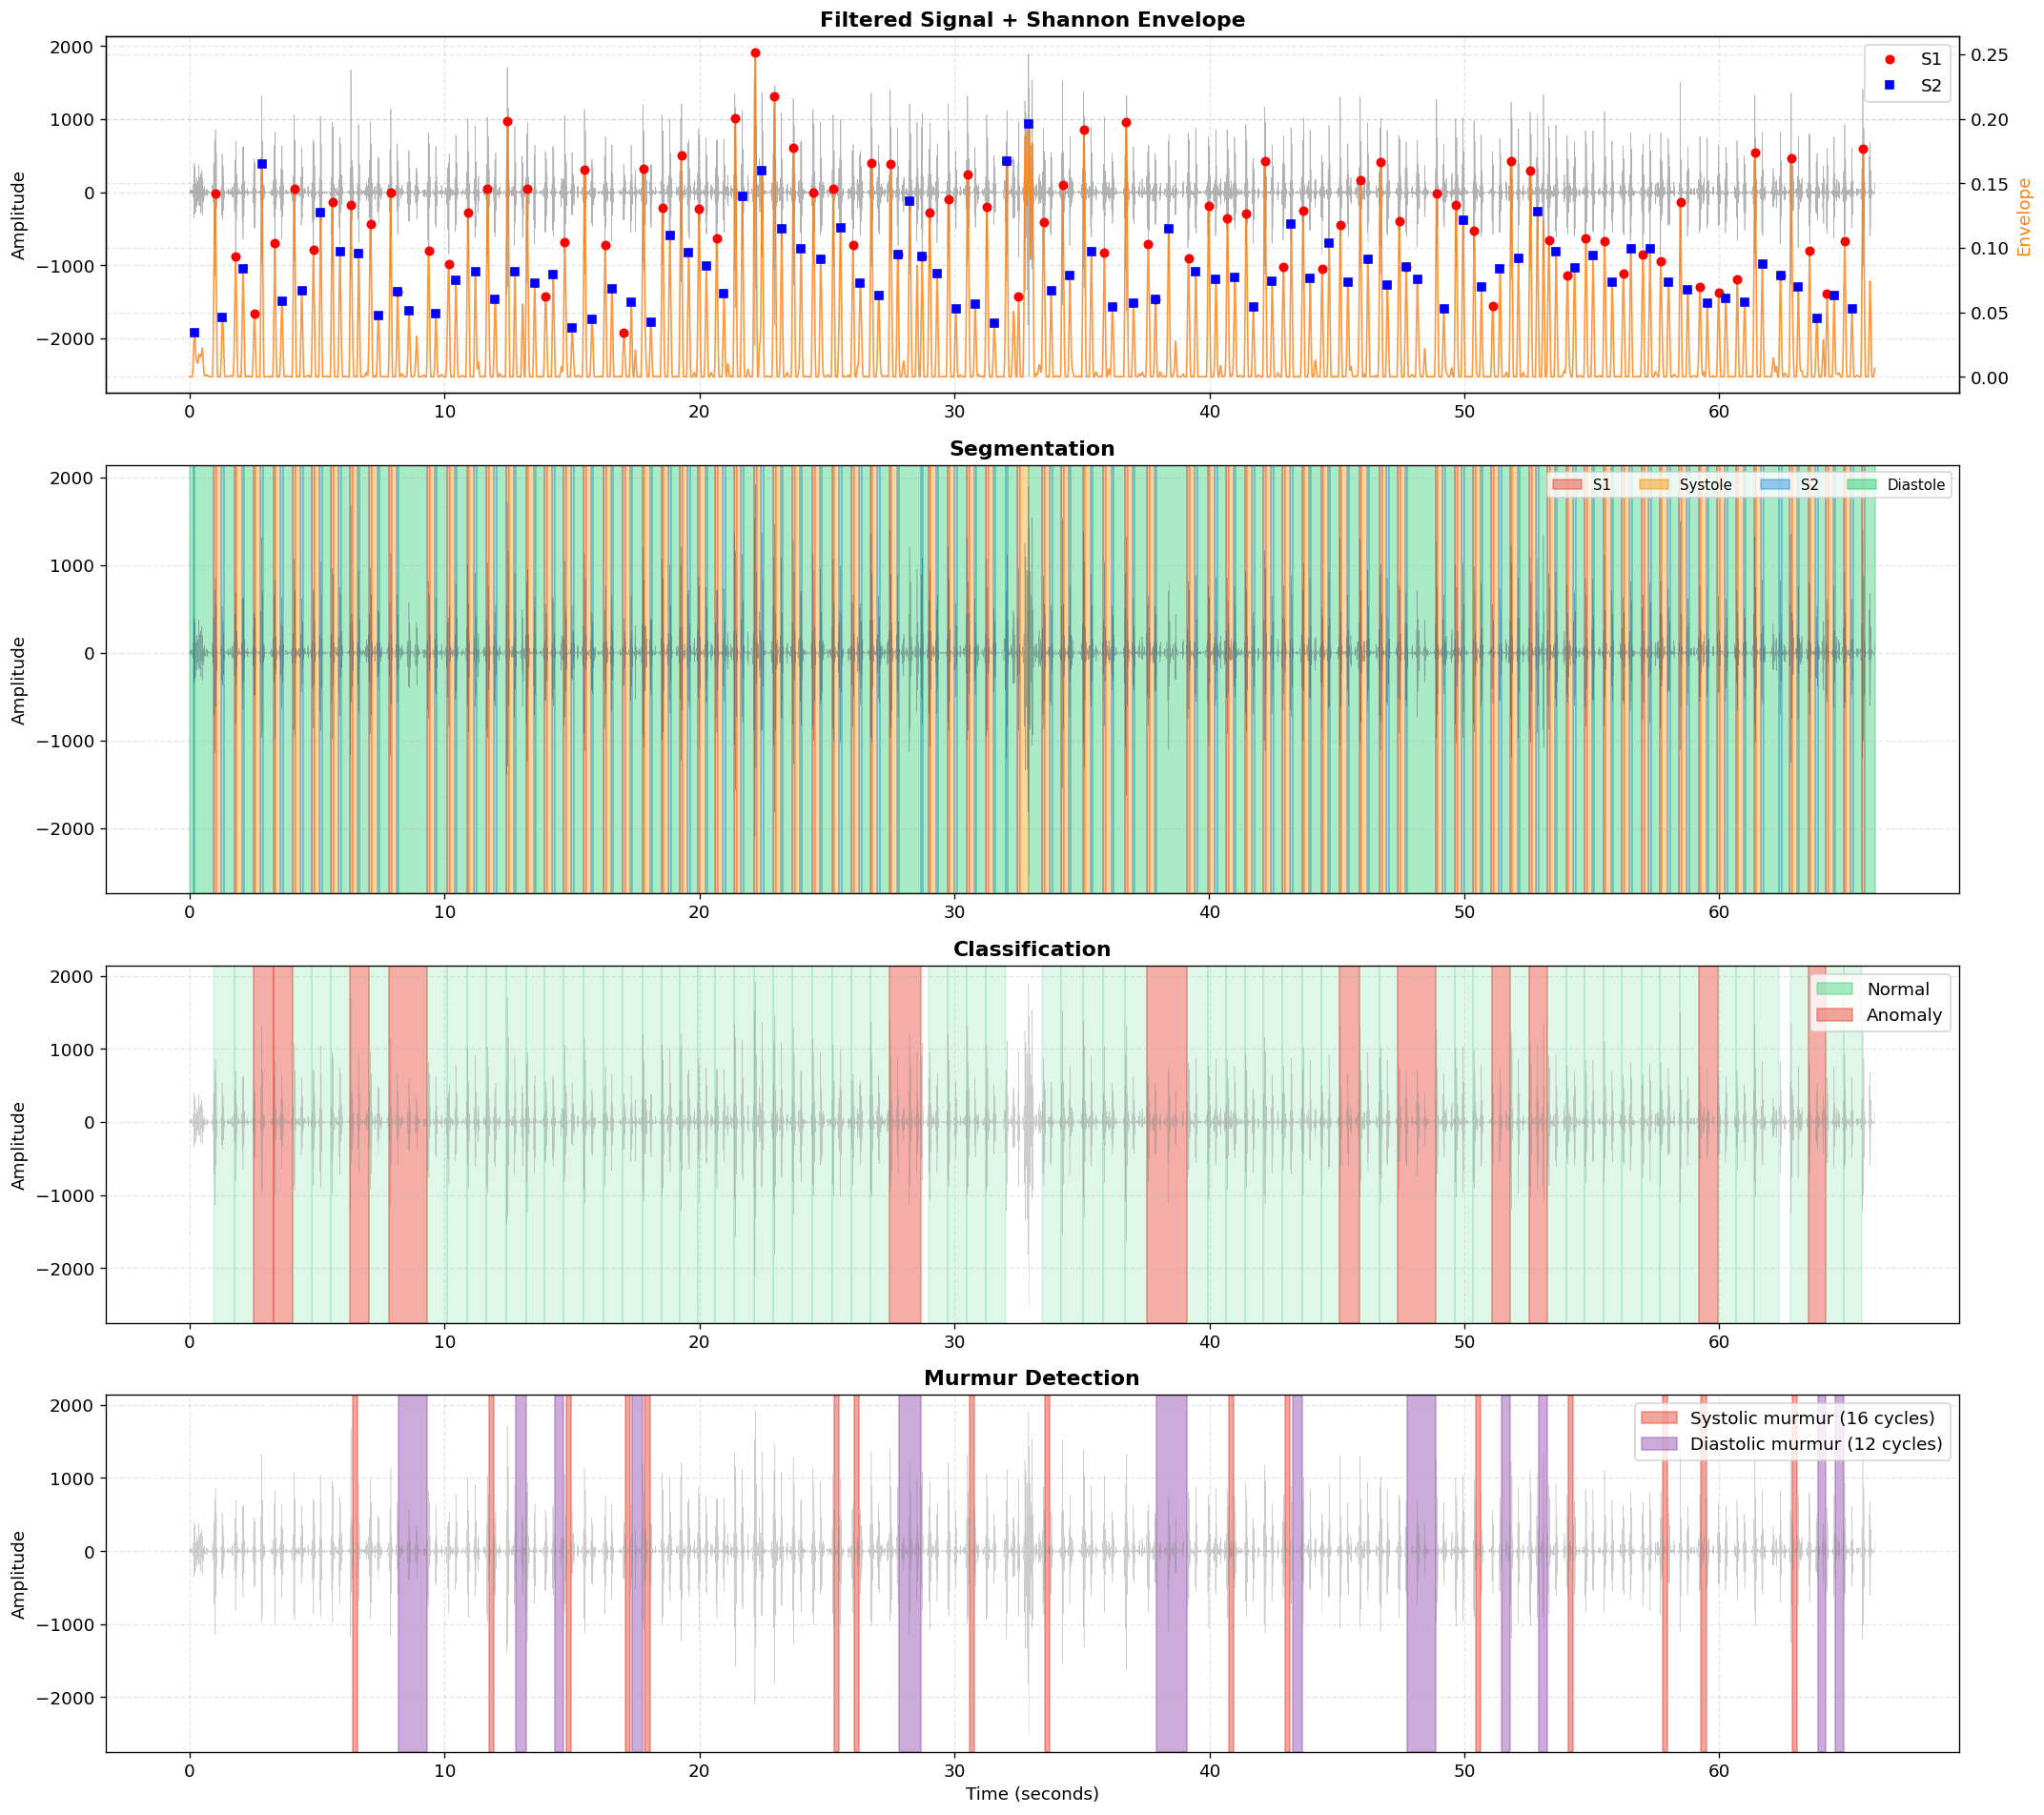

In [ ]:
# All-in-one summary plot
fig, axes = plt.subplots(4, 1, figsize=(18, 16), gridspec_kw={'height_ratios': [1, 1.2, 1, 1]})

# 1. Signal + envelope
axes[0].plot(time_axis, filtered, color='gray', lw=0.4, alpha=0.6)
ax0b = axes[0].twinx()
ax0b.plot(time_axis, envelope, color='#ff7f0e', lw=1, alpha=0.8)
ax0b.set_ylabel('Envelope', color='#ff7f0e')
if len(s1_peaks): ax0b.plot(s1_peaks/sample_rate, envelope[s1_peaks], 'o', color='red', ms=5, label='S1')
if len(s2_peaks): ax0b.plot(s2_peaks/sample_rate, envelope[s2_peaks], 's', color='blue', ms=5, label='S2')
ax0b.legend(loc='upper right')
axes[0].set_title('Filtered Signal + Shannon Envelope', fontweight='bold')
axes[0].set_ylabel('Amplitude')

# 2. Segmentation
axes[1].plot(time_axis, filtered, color='#2c3e50', lw=0.3, alpha=0.4)
for sn, s, e in segments:
    idx = STATE_NAMES.index(sn)
    axes[1].axvspan(s/sample_rate, e/sample_rate, alpha=0.4, color=STATE_COLORS[idx])
axes[1].legend(handles=patches, loc='upper right', fontsize=9, ncol=4)
axes[1].set_title('Segmentation', fontweight='bold')
axes[1].set_ylabel('Amplitude')

# 3. Classification
axes[2].plot(time_axis, filtered, color='gray', lw=0.3, alpha=0.4)
for c, lab in zip(cycles, labels):
    color = '#2ecc71' if lab == 1 else '#e74c3c'
    alpha = 0.15 if lab == 1 else 0.45
    axes[2].axvspan(c['_s1_start']/sample_rate, c['_dia_end']/sample_rate, alpha=alpha, color=color)
axes[2].legend(handles=[mpatches.Patch(color='#2ecc71', alpha=0.4, label='Normal'),
                        mpatches.Patch(color='#e74c3c', alpha=0.5, label='Anomaly')], loc='upper right')
axes[2].set_title('Classification', fontweight='bold')
axes[2].set_ylabel('Amplitude')

# 4. Murmur
axes[3].plot(time_axis, filtered, color='gray', lw=0.3, alpha=0.4)
for c, mr in zip(cycles, murmur_results):
    if mr['systolic_murmur']:
        axes[3].axvspan(c['_sys_start']/sample_rate, c['_sys_end']/sample_rate, alpha=0.5, color='#e74c3c')
    if mr['diastolic_murmur']:
        axes[3].axvspan(c['_dia_start']/sample_rate, c['_dia_end']/sample_rate, alpha=0.5, color='#9b59b6')
axes[3].legend(handles=[sp_, dp_], loc='upper right')
axes[3].set_title('Murmur Detection', fontweight='bold')
axes[3].set_xlabel('Time (seconds)')
axes[3].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()